In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Esto es para obtener el código para el estado

In [2]:
f = '../data/raw/catun_municipio/AGEEML_20258131423976_utf.csv'
ubica_geo = pd.read_csv(f, encoding="utf-8"
                       # usecols = ['folioviv','aire_acond','entidad','factor']
                      )
ubica_geo

,MAPA,CVE_ENT,NOM_ENT,NOM_ABR,CVE_MUN,NOM_MUN,CVE_CAB,NOM_CAB,POB_TOTAL,POB_MASCULINA,POB_FEMENINA,TOTAL DE VIVIENDAS HABITADAS
0,1001,1,Aguascalientes,Ags.,1,Aguascalientes,0001,Aguascalientes,948990,462073,486917,266942
1,1002,1,Aguascalientes,Ags.,2,Asientos,0001,Asientos,51536,25261,26275,12544
2,1003,1,Aguascalientes,Ags.,3,Calvillo,0001,Calvillo,58250,28563,29687,15556
3,1004,1,Aguascalientes,Ags.,4,Cosío,0001,Cosío,17000,8292,8708,3938
4,1005,1,Aguascalientes,Ags.,5,Jesús María,0001,Jesús María,129929,64219,65710,33229
...,...,...,...,...,...,...,...,...,...,...,...,...
2473,32054,32,Zacatecas,Zac.,54,Villa Hidalgo,0001,Villa Hidalgo,19446,9504,9942,4951
2474,32055,32,Zacatecas,Zac.,55,Villanueva,0001,Villanueva,31558,15590,15968,9052
2475,32056,32,Zacatecas,Zac.,56,Zacatecas,0001,Zacatecas,149607,71972,77635,42424
2476,32057,32,Zacatecas,Zac.,57,Trancoso,0001,Trancoso,20455,10039,10416,4671


In [3]:
nombre_edo = "Campeche"
ubica_edo = ubica_geo[ubica_geo["NOM_ENT"].str.contains(nombre_edo, case=False, na=False)]
ubica_edo

,MAPA,CVE_ENT,NOM_ENT,NOM_ABR,CVE_MUN,NOM_MUN,CVE_CAB,NOM_CAB,POB_TOTAL,POB_MASCULINA,POB_FEMENINA,TOTAL DE VIVIENDAS HABITADAS
23,4001,4,Campeche,Camp.,1,Calkiní,0001,Calkiní,59232,29170,30062,15289
24,4002,4,Campeche,Camp.,2,Campeche,0001,San Francisco de Campeche,294077,141555,152522,85353
25,4003,4,Campeche,Camp.,3,Carmen,0001,Ciudad del Carmen,248845,123043,125802,72119
26,4004,4,Campeche,Camp.,4,Champotón,0001,Champotón,78170,39030,39140,21474
27,4005,4,Campeche,Camp.,5,Hecelchakán,0001,Hecelchakán,31917,15713,16204,8292
28,4006,4,Campeche,Camp.,6,Hopelchén,0001,Hopelchén,42140,21328,20812,10243
29,4007,4,Campeche,Camp.,7,Palizada,0001,Palizada,8683,4423,4260,2546
30,4008,4,Campeche,Camp.,8,Tenabo,0001,Tenabo,11452,5797,5655,3066
31,4009,4,Campeche,Camp.,9,Escárcega,0001,Escárcega,59923,29468,30455,16837
32,4010,4,Campeche,Camp.,10,Calakmul,0001,Xpujil,31714,16101,15613,8037


In [4]:
codigo = 4

## Descripción de las variables (carácteristicas de la vivienda sin cargas electricas)
Para la limpieza de datos se utilizaron XXX variables.

### folioviv: Identificador de la vivienda
Identificador de la vivienda compuesto por dos dígitos con la clave de la entidad federativa, uno con el ámbito (urbano, código diferente a 6;
rural, código 6), cuatro dígitos del número consecutivo de la UPM, un dígito de la decena de levantamiento y dos dígitos con un número consecutivo para la vivienda seleccionada. Se ubica en todas las tablas.

Es la llave que nos permite correlacionar difertes tablas de la ENIGH y tal vez de la ENUT XXX. Con el digito que corresponde a rural o urbano, podremos ver cuales datos corresponden a la ciudad y cuales a los pueblos cercanos. 

### ubica_geo: Ubicación geográfica
Contiene la ubicación geográfica de la vivienda. Los dos primeros dígitos representan la clave de la entidad y los siguientes tres la clave del
municipio. Estas corresponden al Catálogo de claves de entidades federativas, municipios y localidades, que está disponible en el sitio del INEGI
https://www.inegi.org.mx/app/ageeml/

Nos permite separar los datos por municipio. Se ubica en la tabla "viviendas".


### factor: Factor de expansión 
El factor de expansión constituye el peso que se le da a cada unidad muestral para generalizar los resultados de la muestra a la población. Se ubica en todas las tablas.

### mat_pared, mat_techos, mat_pisos: Materiales de construcción
Estas tres variables constituyen los materiales de construcción para cada vivienda, utilizandolas se pueden obtener los distintos sistemas constructivos. Se ubica en la tabla "viviendas".

- mat_pared
1. = Material de desecho 
2. = Lámina de cartón  
3. = Lámina de asbesto o metálica 
4. = Carrizo, bambu o palma
5. = Embarro o embajareque
6. = Madera
7. = Adobe
8. = Tabique, ladrillo, block, piedra, cantera, cemento o concreto

- mat_techos
1. = Material de desecho
1. = Lámina de cartón
1. = Lámina metálica
1. = Lámina de asbesto
1. = Lámina de fibrocemento ondulada (techo fijo)
1. = Palma o paja
1. = Madera o tejamanil
1. = Terrado con viguería
1. = Teja
1. = Losa de concreto o viguetas con bovedilla

- mat_pisos
1. = Tierra
1. = Cemento o firme
1. = Madera, mosaico u otro recubrimiento

### disp_elect: Disponibilidad eléctrica
Fuente de donde se obtiene la energía eléctrica en la vivienda. Será útil para seleccionar solo a quienes tienen servicio electrico (para poder asignarles un consumo en kWh a partir de lo que pagaron en MNX del 2024). Se ubica en la tabla "viviendas".

1. = Del servicio público
2. = De una planta particular
3. = De panel solar
4. = De otra fuente
5. = No tiene luz eléctrica

### tot_hog: Total de hogares en la vivienda
En una misma vivienda pueden haber varios hogares, por ejemplo, que en el primer piso viva una familia y en el segundo otra. En este estudio se consideraran a todos los hogares de una vivienda como uno solo. Se ubica en la tabla "viviendas".

### gasto_tri, Gasto trimestral
El gasto trimestral normalizado de acuerdo a la decena de levantamiento en la ENIGH significa que el INEGI ajusta los gastos reportados por los hogares para hacerlos comparables, ya que las entrevistas se realizan en diferentes “decenas de levantamiento” (bloques de 10 días). Como cada hogar declara sus gastos en periodos de referencia distintos según cuándo fue encuestado, la normalización corrige esas diferencias temporales, por ejemplo, variaciones de precios o de temporada y así el gasto trimestral refleja un periodo estándar común para toda la muestra.

Para fines de este trabajo solo se consideran los gastos relacionados con el consumo de electricidad, para ello se filtran los que contengan la clave 045100 y se suman los valores de todos los hogares que habiten en la misma vivienda. 

## Descripción de las variables (carácteristicas de los residentes)

Las variables de esta seccion se encuentran en dos tablas, vivinedas y POBLACION. Todas nos pueden ser útiles para coorelacionar con los datos de la encuesta ENUT.

### tot_resid: Total de residentes de la vivienda
Número de personas que habitan la vivienda, muy útil para los perfiles de ocupación y consumo. Se ubica en la tabla "viviendas".

### est_socio: Estrato socioeconómico
Clasificación de las viviendas del país de acuerdo a ciertas características socioeconómicas de las personas que las habitan, así como características físicas y el equipamiento de las mismas expresadas por medio de 34 indicadores construidos con información del Censo de Población y Vivienda 2010. Esta estratificación se realizó por medio de métodos estadísticos multivariados. Se ubica en la tabla "viviendas".

Será muy útil para formar los grupos y para asignar consumos en el módelo de ML.

1. = Bajo
2. = Medio bajo
3. = Medio alto
4. = Alto

### edu_ini: Asistencia educación inicial
Lugar al que asiste para su educación inicial, se encuentra en la tabla "POBLACION"

1. = Una estancia infantil
2. = Una guardería pública (IMSS, ISSSTE, SEDENA, SEMAR, PEMEX)
3. = Un centro de Desarrollo Infantil (CENDI) o Centro Asistencial de Desarrollo Infantil (CADI)
4. = Educación inicial
5. = Otras guarderías
6. = No asiste a guardería

### asis_esc: Asistencia a la escuela
Situación que distingue a las personas de 3 o más años según asistan o no a algún establecimiento de enseñanza escolar del Sistema Educativo Nacional (SEN), se encuentra en la tabla "POBLACION"

1. = Sí
2. = No

### nivel: Nivel escolar al que asiste
Nivel al que asiste a la escuela el integrante del hogar de 3 o más años dentro del Sistema Educativo Nacional, se encuentra en la tabla "POBLACION".

1. = Estancias infantiles
1. = Guarderías públicas (IMSS, ISSSTE, SEDENA, SEMAR, PEMEX)
1. = Centro de Desarrollo Infantil (CENDI) o Centro Asistencial de Desarrollo Infantil (CADI)
1. = Otras guarderías
1. = Preescolar o kinder
1. = Primaria
1. = Secundaria
1. = Estudios técnicos con secundaria terminada
1. = Preparatoria o bachillerato
1. = Estudios técnicos con preparatoria terminada
1. = Licenciatura o Ingeniería (profesional)
1. = Especialidad
1. = Maestría
1. = Doctorado

### grado: Grado escolar al que asiste
Grado al que asiste a la escuela el integrante del hogar de 3 o más años dentro del Sistema Educativo Nacional, se encuentra en la tabla "POBLACION". 

1. = Primer año
2. = Segundo año
3. = Tercer año
4. = Cuarto año
5. = Quinto año
6. = Sexto año

### Uso del tiempo 
Las siguientes variables corresponden al uso del tiempo de los residentes de cada vivienda. Todos incluyen un avariable para las horas y otra para los minutos que realizaron dicha actividad durante la semana pasada, así como una variable para indicar si la persona realizó o no la actividad o si no lo recuerda (tomando valores de 8 y 9 en cada caso), todas se encuentran en la tabla "POBLACION". 

* Horas y minutos de trabajo (hor_1, min_1)
* No trabajó o no recuerda haber trabajado (usotiempo1)
* Horas y minutos de estudio (hor_2, min_2)
* No estudió o no recuerda haber estudiado (usotiempo2)
* Horas y minutos de trabajo comunitario voluntario (hor_3, min_3)
* No hizo o no recuerda haber hecho trabajo comunitario voluntario (usotiempo3)
* Horas y minutos dedicados al cuidado de otras personas sin pago (hor_4, min_4)
* No cuido o no recuerda haber cuidado a otros sin pago (usotiempo4)
* Horas y minutos dedicados a reparaciones o mantenimiento en la vivienda (hor_5, min_5)
* No realizo o no recuerda haber realizado reparaciones o mantenimiento (usotiempo5)
* Horas y minutos dedicados a quehacer (hor_6, min_6)
* No hizo quehacer o no recuerda haber hecho quehacer (usotiempo6)
* Horas y minutos dedicados a acarrear agua o leña (hor_7, min_7)
* No acarreo o no recuerda haber acarreado (usotiempo7)
* Horas y minutos dedicados a actividades de su gusto (hor_8, min_8)
* No dedico tiempo a su guto o no recuerda haberlo hecho (usotiempo8)

## Descripción de las variables (solo cargas electricas)

Una enorme desventaja es que en la ENIGH no se pregunta cuánto tiempo a la semana se utilizan las cargas, podríamos intentar asignarlo con los datos de la ENCEVI, donde si lo preguntan. 

### aire_acond, calefacc: Aire acondicionado y calefacción 
Estas variables representan las cargas electricas más importantes en una vivienda, no se explicita con cuántos equipos se cuenta. Se ubica en la tabla "viviendas". 

- aire_acond
1. = Sí
2. = No

- calefacc
1. = Sí
2. = No

### focos, focos_ahor: Número total de focos y de focos ahorradores
Total de focos que se usan para iluminar la vivienda, tanto en el interior como en el exterior, en focos se muestra tanto ahorradores como no ahorradores. XXX no especifica cuánto consume un foco ahorrador. Se ubica en la tabla "viviendas". 

### combus: Tipo de ombustible para cocinar
Si es electricidad (5) va a representar una carga electrica importante. Se ubica en la tabla "viviendas".

1. = Leña
2. = Carbón
3. = Gas de tanque
4. = Gas natural o de tubería
5. = Electricidad
6. = Otro combustible
7. = No cocinan


### telefono, celular: Linea telefónica fija y telefono celular
Solo indica si se tiene, pero no en qué cantidad, solo se puede obter cuánto dinero se gasto en celulares el último semestre, pero no con cuántos cuentan. Se ubican en la tabla "viviendas". 
- telefono
1. = Sí
2. = No

- celular
1. = Sí
2. = No

### Numero de electrodomesticos
Aquí se muestran muchas variables de la tabla hogar, todas representan la cantidad de equipos con los que se cuenta, pero no las horas a la semana que se utilizan. Para cada aparato existe otra pregunta para el año en el que se adquierio el más reciente, podríamos usar esto para seleccionar uno y de ahí su consumo, por ejemplo, con consolas de videojuegos, si el año más repetido de cada grupo fue 2018, podemos seleccionar la que más se vendió en México. El valor -1, representa un dato “no especificado”. Se ubican en la tabla "viviendas". 

- num_venti: Número de ventiladores del hogar
- num_ester: Número de estéreos del hogar
- num_radio: Número de radios del hogar
- num_tva: Número de televisores analógicos del hogar
- num_tvd: Número de televisores digitales del hogar
- num_dvd: Número de DVD del hogar
- num_licua: Número de licuadoras del hogar
- num_tosta: Número de tostadores del hogar
- num_micro: Número de hornos de microondas del hogar
- num_refri: Número de refrigeradores del hogar
- num_estuf: Número de estufas del hogar (revisar en "combus" si es electrica)
- num_lavad: Número de lavadoras del hogar
- num_planc: Número de planchas del hogar
- num_maqui: Número de máquinas de coser del hogar
- num_aspir: Número de aspiradoras del hogar
- num_compu: Número de computadoras del hogar
- num_lap: Número de laptop del hogar
- num_table: Número de tablet del hogar
- num_impre: Número de impresoras del hogar
- num_juego: Número de consola de videojuegos

## Como coorrelacionar las encuestas ENIGH y ENUT

No se pueden correlacionar directamente a nivel de individuo o de hogar, porque cada encuesta tiene su propio marco muestral y su propio levantamiento. Es decir, las encuestas no entrevistan a las mismas personas ni usan un identificador común que permita “unir” observaciones una a una. Por estas razones, es necesario encontrar caracteristicas que compartan ambas encuestas para poder separar grupos y determinar indices de cada uno, por ejemplo, por el estado y estrato economico, etc. 


## Importar y acotar tabla VIVIENDA

In [5]:
f = '../data/raw/enigh2024_ns_viviendas_csv/viviendas.csv'
VIVIENDA = pd.read_csv(f, 
                       usecols = ['folioviv','ubica_geo','factor','tipo_viv',
                                  'mat_pared','mat_techos','mat_pisos',
                                  'cuart_dorm','num_cuarto',
                                  # no se incluyeron banos
                                  'disp_elect',
                                  'tot_resid','est_socio',
                                  # 'tot_hog',
                                  # Abajo son cargas electricas
                                  'aire_acond','calefacc',
                                  'focos','focos_ahor', 
                                  'combus'] #Es el combustible para cocinar, si es electricidad (5) va a representar una carga electrica importante
                      )
VIVIENDA

C:\Users\roele\AppData\Local\Temp\ipykernel_27140\4140414600.py:2: DtypeWarning: Columns (1,4,27) have mixed types. Specify dtype option on import or set low_memory=False.
  VIVIENDA = pd.read_csv(f,


,folioviv,tipo_viv,mat_pared,mat_techos,mat_pisos,cuart_dorm,num_cuarto,disp_elect,focos,focos_ahor,combus,aire_acond,calefacc,tot_resid,ubica_geo,est_socio,factor
0,100001901,7,8,10,3,1,4,1,9,9,3,2,2,4,1001,3,207
1,100001902,1,8,10,3,3,4,1,10,10,3,2,2,4,1001,3,207
2,100001904,1,8,10,3,2,3,1,11,11,3,2,2,2,1001,3,207
3,100001905,1,8,10,3,2,3,1,6,6,3,2,2,4,1001,3,207
4,100002501,4,8,10,3,2,3,1,8,8,3,2,2,4,1001,2,196
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90319,3260593814,1,8,10,3,1,2,1,4,3,3,2,2,3,32052,2,183
90320,3260593815,1,8,10,2,2,4,1,7,5,3,2,2,5,32052,2,183
90321,3260593816,1,8,10,3,2,3,1,5,0,3,2,2,5,32052,2,183
90322,3260593817,1,8,10,2,3,4,1,5,5,3,2,2,2,32052,2,183


In [6]:
VIVIENDA.dtypes

folioviv       int64
tipo_viv      object
mat_pared      int64
mat_techos     int64
mat_pisos     object
cuart_dorm     int64
num_cuarto     int64
disp_elect     int64
focos         object
focos_ahor    object
combus        object
aire_acond     int64
calefacc       int64
tot_resid      int64
ubica_geo      int64
est_socio      int64
factor         int64
dtype: object

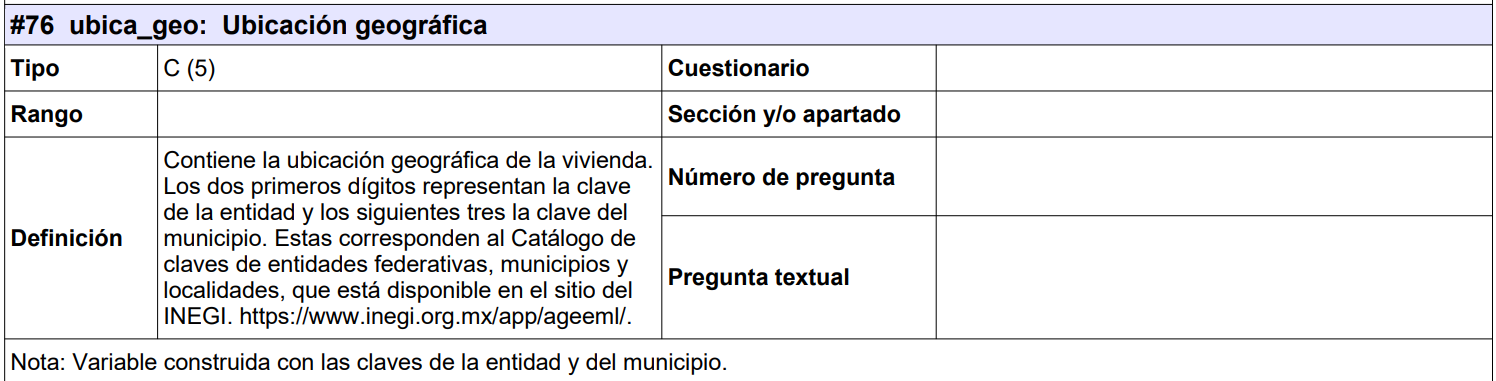

In [7]:
VIVIENDA_edo = VIVIENDA[VIVIENDA['ubica_geo'].astype(str).str.startswith(f'{codigo}')].copy()
VIVIENDA_edo

,folioviv,tipo_viv,mat_pared,mat_techos,mat_pisos,cuart_dorm,num_cuarto,disp_elect,focos,focos_ahor,combus,aire_acond,calefacc,tot_resid,ubica_geo,est_socio,factor
9635,401161019,1,8,10,3,3,5,1,9,9,3,2,2,2,4001,2,141
9636,401161020,2,8,10,3,2,2,1,4,4,3,2,2,1,4001,2,141
9637,401161021,1,8,10,3,1,1,1,4,4,1,2,2,2,4001,2,141
9638,401161022,2,8,10,3,2,3,1,5,5,3,2,2,4,4001,2,141
9639,401161024,1,8,10,3,2,2,1,8,8,3,2,2,4,4001,2,141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11824,461430920,1,6,3,1,2,3,3,2,2,2,2,2,7,4011,1,124
11825,461430921,1,6,3,2,1,2,1,3,3,1,2,2,1,4011,1,124
11826,461430922,1,6,3,2,1,1,1,3,3,3,2,2,4,4011,1,124
11827,461430923,1,6,3,2,1,1,1,3,3,1,2,2,2,4011,1,124


## Importar tabla HOGAR para el estado 

In [8]:
f = '../data/raw/enigh2024_ns_hogares_csv/hogares.csv'
HOGAR = pd.read_csv(f, 
                       usecols = ['folioviv',
                                  'telefono', 'celular', 
                                  'num_venti', 'num_ester', 'num_radio', 'num_tva', 'num_tvd', 'num_dvd', 'num_licua', 
                                  'num_tosta', 'num_micro', 'num_refri', 'num_estuf', 'num_lavad', 'num_planc', 'num_maqui', 
                                  'num_aspir', 'num_compu', 'num_lap', 'num_table', 'num_impre', 'num_juego']
                      )
HOGAR

,folioviv,telefono,celular,num_ester,num_radio,num_tva,num_tvd,num_dvd,num_licua,num_tosta,...,num_lavad,num_planc,num_maqui,num_venti,num_aspir,num_compu,num_lap,num_table,num_impre,num_juego
0,100001901,2,1,0,0,0,1,1,1,0,...,1,1,0,1,0,0,1,0,0,0
1,100001902,1,1,0,1,0,1,1,1,0,...,1,1,0,0,0,0,1,0,1,0
2,100001904,1,1,0,0,0,2,0,1,0,...,1,1,1,1,0,0,0,0,0,0
3,100001905,1,1,1,0,0,2,0,1,0,...,1,1,0,0,0,0,0,1,0,0
4,100002501,1,1,1,0,0,2,0,1,0,...,1,1,0,0,0,0,0,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91409,3260593814,2,1,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
91410,3260593815,2,1,0,0,0,1,0,1,0,...,1,1,0,1,0,0,1,1,1,0
91411,3260593816,2,1,1,0,0,1,0,1,0,...,1,0,0,0,0,0,0,0,0,0
91412,3260593817,1,1,1,0,0,1,0,1,0,...,0,0,0,0,0,0,1,0,0,0


In [9]:
HOGAR_repetidos = HOGAR[HOGAR['folioviv'].isin(HOGAR['folioviv'][HOGAR['folioviv'].duplicated(keep=False)])].copy()
HOGAR_repetidos

,folioviv,telefono,celular,num_ester,num_radio,num_tva,num_tvd,num_dvd,num_licua,num_tosta,...,num_lavad,num_planc,num_maqui,num_venti,num_aspir,num_compu,num_lap,num_table,num_impre,num_juego
405,100073403,1,1,0,1,0,2,0,1,0,...,0,0,0,0,0,0,0,0,0,0
406,100073403,1,1,0,0,0,0,0,1,0,...,1,1,0,0,0,0,0,0,0,0
470,100085302,2,2,0,0,0,1,0,1,0,...,1,0,0,0,0,0,0,0,0,0
471,100085302,2,1,0,0,0,1,0,1,0,...,1,0,0,0,0,0,1,0,0,0
954,100172706,2,2,0,1,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91131,3260581023,2,1,0,1,1,1,0,1,0,...,0,1,0,0,0,0,0,0,0,0
91182,3260583305,2,1,0,1,0,1,0,1,0,...,1,0,0,1,0,0,0,0,0,0
91183,3260583305,2,1,0,0,0,2,0,1,0,...,1,1,0,0,0,0,0,0,0,1
91271,3260587717,2,2,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
cols_sumar = [
    'num_venti', 'num_ester', 'num_radio', 'num_tva', 'num_tvd', 'num_dvd', 'num_licua', 
    'num_tosta', 'num_micro', 'num_refri', 'num_estuf', 'num_lavad', 'num_planc', 'num_maqui', 
    'num_aspir', 'num_compu', 'num_lap', 'num_table', 'num_impre', 'num_juego'
]

def telefono_rule(x):
    return 1 if (x == 1).any() else 2

HOGAR = HOGAR.groupby('folioviv').agg(
    {**{col: 'sum' for col in cols_sumar},
     'telefono': telefono_rule,
     'celular': telefono_rule}
).reset_index()

HOGAR

,folioviv,num_venti,num_ester,num_radio,num_tva,num_tvd,num_dvd,num_licua,num_tosta,num_micro,...,num_planc,num_maqui,num_aspir,num_compu,num_lap,num_table,num_impre,num_juego,telefono,celular
0,100001901,1,0,0,0,1,1,1,0,1,...,1,0,0,0,1,0,0,0,2,1
1,100001902,0,0,1,0,1,1,1,0,0,...,1,0,0,0,1,0,1,0,1,1
2,100001904,1,0,0,0,2,0,1,0,1,...,1,1,0,0,0,0,0,0,1,1
3,100001905,0,1,0,0,2,0,1,0,1,...,1,0,0,0,0,1,0,0,1,1
4,100002501,0,1,0,0,2,0,1,0,0,...,1,0,0,0,0,2,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90319,3260593814,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,2,1
90320,3260593815,1,0,0,0,1,0,1,0,1,...,1,0,0,0,1,1,1,0,2,1
90321,3260593816,0,1,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,2,1
90322,3260593817,0,1,0,0,1,0,1,0,0,...,0,0,0,0,1,0,0,0,1,1


In [11]:
HOGAR_edo = HOGAR[HOGAR['folioviv'].isin(VIVIENDA_edo['folioviv'])].copy()
HOGAR_edo

,folioviv,num_venti,num_ester,num_radio,num_tva,num_tvd,num_dvd,num_licua,num_tosta,num_micro,...,num_planc,num_maqui,num_aspir,num_compu,num_lap,num_table,num_impre,num_juego,telefono,celular
9635,401161019,1,0,1,0,1,0,1,0,1,...,1,0,0,0,0,0,0,0,2,1
9636,401161020,1,0,0,0,1,0,1,0,0,...,1,0,0,0,0,0,0,0,2,1
9637,401161021,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,2,1
9638,401161022,1,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,2,1
9639,401161024,2,0,0,0,2,0,1,0,1,...,1,1,0,0,1,0,0,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11824,461430920,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,1
11825,461430921,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,2,1
11826,461430922,1,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,2,1
11827,461430923,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,2,1


## Importar tabla POBLACION para edo

In [12]:
f = '../data/raw/enigh2024_ns_poblacion_csv/poblacion.csv'
POBLACION = pd.read_csv(f,
                         usecols = ['folioviv','foliohog','edad','sexo',
                                    'numren', #Identificador de la persona 
                                    'edu_ini','asis_esc','nivel','grado',
                                    'hor_1','min_1','usotiempo1',
                                    'hor_2','min_2','usotiempo2',
                                    'hor_3','min_3','usotiempo3',
                                    'hor_4','min_4','usotiempo4',
                                    'hor_5','min_5','usotiempo5',
                                    'hor_6','min_6','usotiempo6',
                                    'hor_7','min_7','usotiempo7',
                                    'hor_8','min_8','usotiempo8'
                        ]
                      )
POBLACION

,folioviv,foliohog,numren,sexo,edad,edu_ini,asis_esc,nivel,grado,hor_1,...,usotiempo5,hor_6,min_6,usotiempo6,hor_7,min_7,usotiempo7,hor_8,min_8,usotiempo8
0,100001901,1,1,1,32,NaN,2.0,NaN,NaN,48,...,9.0,5,0,NaN,,,9.0,14,0,NaN
1,100001901,1,2,2,24,NaN,2.0,NaN,NaN,45,...,9.0,21,0,NaN,,,9.0,2,0,NaN
2,100001901,1,3,2,5,NaN,1.0,5.0,3.0,,...,NaN,,,NaN,,,NaN,,,NaN
3,100001901,1,4,1,2,6.0,NaN,NaN,NaN,,...,NaN,,,NaN,,,NaN,,,NaN
4,100001902,1,1,1,48,NaN,2.0,NaN,NaN,48,...,9.0,3,0,NaN,,,9.0,14,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308593,3260593816,1,5,1,12,NaN,1.0,7.0,1.0,,...,9.0,,,9.0,,,9.0,22,0,NaN
308594,3260593817,1,1,1,53,NaN,2.0,NaN,NaN,,...,9.0,,,9.0,,,9.0,12,0,NaN
308595,3260593817,1,2,2,54,NaN,2.0,NaN,NaN,80,...,9.0,2,0,NaN,,,9.0,,,9.0
308596,3260593818,1,1,2,63,NaN,2.0,NaN,NaN,,...,9.0,14,0,NaN,,,9.0,16,0,NaN


In [13]:
POBLACION_edo = POBLACION[POBLACION['folioviv'].isin(VIVIENDA_edo['folioviv'])].copy()
POBLACION_edo

,folioviv,foliohog,numren,sexo,edad,edu_ini,asis_esc,nivel,grado,hor_1,...,usotiempo5,hor_6,min_6,usotiempo6,hor_7,min_7,usotiempo7,hor_8,min_8,usotiempo8
31594,401161019,1,1,1,82,NaN,2.0,NaN,NaN,17,...,9.0,,,9.0,,,9.0,70,0,NaN
31595,401161019,1,2,2,63,NaN,2.0,NaN,NaN,15,...,9.0,42,0,NaN,,,9.0,14,0,NaN
31596,401161020,1,1,2,47,NaN,2.0,NaN,NaN,40,...,9.0,35,0,NaN,,,9.0,14,0,NaN
31597,401161021,1,1,1,71,NaN,2.0,NaN,NaN,14,...,9.0,7,0,NaN,21,0,NaN,21,0,NaN
31598,401161021,1,2,2,69,NaN,2.0,NaN,NaN,,...,9.0,49,0,NaN,,,9.0,28,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39268,461430922,1,4,1,25,NaN,2.0,NaN,NaN,10,...,9.0,1,0,NaN,,,9.0,70,0,NaN
39269,461430923,1,1,1,40,NaN,2.0,NaN,NaN,66,...,9.0,4,0,NaN,8,0,NaN,14,0,NaN
39270,461430923,1,2,2,29,NaN,2.0,NaN,NaN,14,...,9.0,21,0,NaN,,,9.0,63,0,NaN
39271,461430924,1,1,1,70,NaN,2.0,NaN,NaN,62,...,9.0,3,0,NaN,,,9.0,20,0,NaN


# Importar tabla GASTOHOGAR, filtrar gastos de electricidad por vivienda para el estado

In [14]:
f = '../data/raw/enigh2024_ns_gastoshogar_csv/gastoshogar.csv'
GASTOHOGAR = pd.read_csv(f, 
                       usecols = ['folioviv',
                                  'foliohog',
                                  'clave',
                                  # 'mes_dia','fecha_adqu','cantidad', 'gasto', 'costo',
                                  'gasto_tri',
                                  # 'entidad',
                                  # 'factor'
                                 ]
                      )
GASTOHOGAR

,folioviv,foliohog,clave,gasto_tri
0,100001901,1,011131,167.14
1,100001901,1,011150,642.85
2,100001901,1,011231,192.85
3,100001901,1,011411,488.57
4,100001901,1,011460,1465.71
...,...,...,...,...
5311492,3260593818,1,131208,300
5311493,3260593818,1,13120A,210
5311494,3260593818,1,13120L,360
5311495,3260593818,1,181126,192.85


In [15]:
# solo nos quedamos con los que sean de electricidad clave = 045100
GASTOHOGAR_luz = GASTOHOGAR[GASTOHOGAR['clave'] == '045100'].copy()
GASTOHOGAR_luz['gasto_tri'] = pd.to_numeric(GASTOHOGAR_luz['gasto_tri'], errors='coerce')
GASTOHOGAR_luz = GASTOHOGAR_luz.drop(columns = ['foliohog','clave'])

#Vamos a reducir de hogares a viviendas, para ello se sumaran los valores de gasto_tri de todos los hogares de cada vivienda 
GASTOHOGAR_luz = GASTOHOGAR_luz.groupby('folioviv', as_index=False)['gasto_tri'].sum()
GASTOHOGAR_luz

,folioviv,gasto_tri
0,100001901,195.0
1,100001902,900.0
2,100001904,663.0
3,100001905,274.5
4,100002501,481.5
...,...,...
82089,3260593814,180.0
82090,3260593815,450.0
82091,3260593816,420.0
82092,3260593817,180.0


In [16]:
GASTOHOGAR_luz_edo = GASTOHOGAR_luz[GASTOHOGAR_luz['folioviv'].isin(VIVIENDA_edo['folioviv'])].copy()
GASTOHOGAR_luz_edo

,folioviv,gasto_tri
8865,401161020,375.0
8866,401161021,582.0
8867,401161022,727.5
8868,401161024,450.0
8869,401161301,387.0
...,...,...
10891,461430718,0.0
10892,461430920,60.0
10893,461430922,60.0
10894,461430923,75.0


# Obtener edo_df con los datos de VIVIENDA, HOGAR, GASTOHOGAR

In [17]:
VIVIENDA_edo.columns

Index(['folioviv', 'tipo_viv', 'mat_pared', 'mat_techos', 'mat_pisos',
       'cuart_dorm', 'num_cuarto', 'disp_elect', 'focos', 'focos_ahor',
       'combus', 'aire_acond', 'calefacc', 'tot_resid', 'ubica_geo',
       'est_socio', 'factor'],
      dtype='object')

In [18]:
HOGAR_edo.columns

Index(['folioviv', 'num_venti', 'num_ester', 'num_radio', 'num_tva', 'num_tvd',
       'num_dvd', 'num_licua', 'num_tosta', 'num_micro', 'num_refri',
       'num_estuf', 'num_lavad', 'num_planc', 'num_maqui', 'num_aspir',
       'num_compu', 'num_lap', 'num_table', 'num_impre', 'num_juego',
       'telefono', 'celular'],
      dtype='object')

In [19]:
GASTOHOGAR_luz_edo.columns

Index(['folioviv', 'gasto_tri'], dtype='object')

In [20]:
VIVIENDA_HOGAR_edo = pd.merge(
    VIVIENDA_edo,
    HOGAR_edo,
    on='folioviv',
    how='outer',
    indicator=False
)


In [21]:
# Merge completo con VIVIENDA_HOGAR_edo y GASTOHOGAR_luz_edo
edo_df = pd.merge(
    VIVIENDA_HOGAR_edo,
    GASTOHOGAR_luz_edo,
    on='folioviv',
    how='outer',   # conserva todos los registros de ambos DataFrames
    indicator=False # opcional, para ver de dónde viene cada fila
)

In [22]:
edo_df.isna().sum()

folioviv        0
tipo_viv        0
mat_pared       0
mat_techos      0
mat_pisos       0
cuart_dorm      0
num_cuarto      0
disp_elect      0
focos           0
focos_ahor      0
combus          0
aire_acond      0
calefacc        0
tot_resid       0
ubica_geo       0
est_socio       0
factor          0
num_venti       0
num_ester       0
num_radio       0
num_tva         0
num_tvd         0
num_dvd         0
num_licua       0
num_tosta       0
num_micro       0
num_refri       0
num_estuf       0
num_lavad       0
num_planc       0
num_maqui       0
num_aspir       0
num_compu       0
num_lap         0
num_table       0
num_impre       0
num_juego       0
telefono        0
celular         0
gasto_tri     163
dtype: int64

In [23]:
edo_df.columns

Index(['folioviv', 'tipo_viv', 'mat_pared', 'mat_techos', 'mat_pisos',
       'cuart_dorm', 'num_cuarto', 'disp_elect', 'focos', 'focos_ahor',
       'combus', 'aire_acond', 'calefacc', 'tot_resid', 'ubica_geo',
       'est_socio', 'factor', 'num_venti', 'num_ester', 'num_radio', 'num_tva',
       'num_tvd', 'num_dvd', 'num_licua', 'num_tosta', 'num_micro',
       'num_refri', 'num_estuf', 'num_lavad', 'num_planc', 'num_maqui',
       'num_aspir', 'num_compu', 'num_lap', 'num_table', 'num_impre',
       'num_juego', 'telefono', 'celular', 'gasto_tri'],
      dtype='object')

### Caracteristicas de la vivienda 
'folioviv', 'mat_pared', 'mat_techos', 'mat_pisos', 'cuart_dorm',
'num_cuarto', **'tot_resid'**, 'ubica_geo','est_socio', 
'factor',**'gasto_tri'**
'disp_elect' Esta varaible es solo para limpiar y quitar los que no tienen acceso al servicio de electricidad. 
### Cargas
'focos', 'focos_ahor', 'combus', 'aire_acond', 'calefacc', 
'num_venti', 'num_ester', 'num_radio', 'num_tva',
'num_tvd', 'num_dvd', 'num_licua', 'num_tosta', 'num_micro',
'num_refri', 'num_estuf', 'num_lavad', 'num_planc', 'num_maqui',
'num_aspir', 'num_compu', 'num_lap', 'num_table', 'num_impre',
'num_juego', 'telefono', 'celular'

### Utiles para agrupar
'aire_acond', 'calefacc', 'est_socio', 'num_cuarto', 'tot_resid'
'ubica_geo' Para otro analisis si, aca es un solo municipio

### Variables que me gustaria obtener con modelos o con otras encuestas
Consumo en kWh, superficie de construccion, factores relacionados con horarios de ocupacion y consumo

In [24]:
variables = ['num_cuarto', 
             # 'disp_elect', 
             'ubica_geo','est_socio', 'aire_acond', 'calefacc', 'tot_resid']

# Número de opciones distintas por variable (excluyendo NaN)
opciones = edo_df[variables].nunique(dropna=True)

print(f"Opciones por variable para {nombre_edo}:\n", opciones)

# Producto de todas las opciones
producto = np.prod(opciones)

print("\nTotal de grupos:", producto)


Opciones por variable para Campeche:
 num_cuarto    11
ubica_geo     11
est_socio      4
aire_acond     2
calefacc       2
tot_resid     14
dtype: int64

Total de grupos: 27104


In [25]:
variables = ['num_cuarto', 
             # 'disp_elect', 
             'ubica_geo','est_socio', 'aire_acond', 'calefacc', 'tot_resid']

# Número de opciones distintas por variable (excluyendo NaN)
opciones = VIVIENDA_edo[variables].nunique(dropna=True)

print(f"Opciones por variable para {nombre_edo}:\n", opciones)

# Producto de todas las opciones
producto = np.prod(opciones)

print("\nTotal de grupos:", producto)


Opciones por variable para Campeche:
 num_cuarto    11
ubica_geo     11
est_socio      4
aire_acond     2
calefacc       2
tot_resid     14
dtype: int64

Total de grupos: 27104


In [26]:
conteo = edo_df['ubica_geo'].value_counts()
conteo

ubica_geo
4003    676
4002    672
4001    187
4009    131
4011    110
4006     90
4010     87
4004     86
4008     69
4005     66
4012     20
Name: count, dtype: int64

800 son demasiados, hay que acotar en total de residentes y numero de cuartos

In [27]:
variables_agrupar = [
    'num_cuarto', 
    # 'disp_elect',
    # 'est_socio', 
    # 'aire_acond', 
    # 'calefacc', 
    'tot_resid'
]

conteos_ponderados = {}

for col in variables_agrupar:
    # Conteo ponderado
    conteo = (
        edo_df
        .groupby(col)['factor']
        .sum()
        .sort_values(ascending=False)
    )
    
    # Calcular porcentaje
    porcentaje = (conteo / conteo.sum()) * 100
    
    # Unir en un DataFrame
    resumen = pd.DataFrame({
        'conteo_ponderado': conteo,
        'porcentaje': porcentaje.round(2)  # redondear a 2 decimales
    })
    
    conteos_ponderados[col] = resumen

# Mostrar resultados
for col, resumen in conteos_ponderados.items():
    print("\n-----------")
    print(f"{col} (ponderado y porcentaje)\n")
    print(resumen)



-----------
num_cuarto (ponderado y porcentaje)

            conteo_ponderado  porcentaje
num_cuarto                              
3                      80207       29.65
4                      62260       23.01
2                      55517       20.52
5                      29030       10.73
1                      25385        9.38
6                      11767        4.35
7                       3415        1.26
8                       1822        0.67
9                        651        0.24
14                       239        0.09
10                       234        0.09

-----------
tot_resid (ponderado y porcentaje)

           conteo_ponderado  porcentaje
tot_resid                              
4                     60775       22.47
3                     56647       20.94
2                     56426       20.86
5                     33602       12.42
1                     31182       11.53
6                     16727        6.18
7                      8301        3.07
8       

In [28]:
variables = [
             # 'num_cuarto', 
             # 'disp_elect', 
             'est_socio', 
             'aire_acond', 
             'calefacc', 
             # 'tot_resid'
            ]

# Número de opciones distintas por variable (excluyendo NaN)
opciones = edo_df[variables].nunique(dropna=True)
producto = np.prod(opciones)*5*5
print("\nGrupos reducidos:", producto)


Grupos reducidos: 400


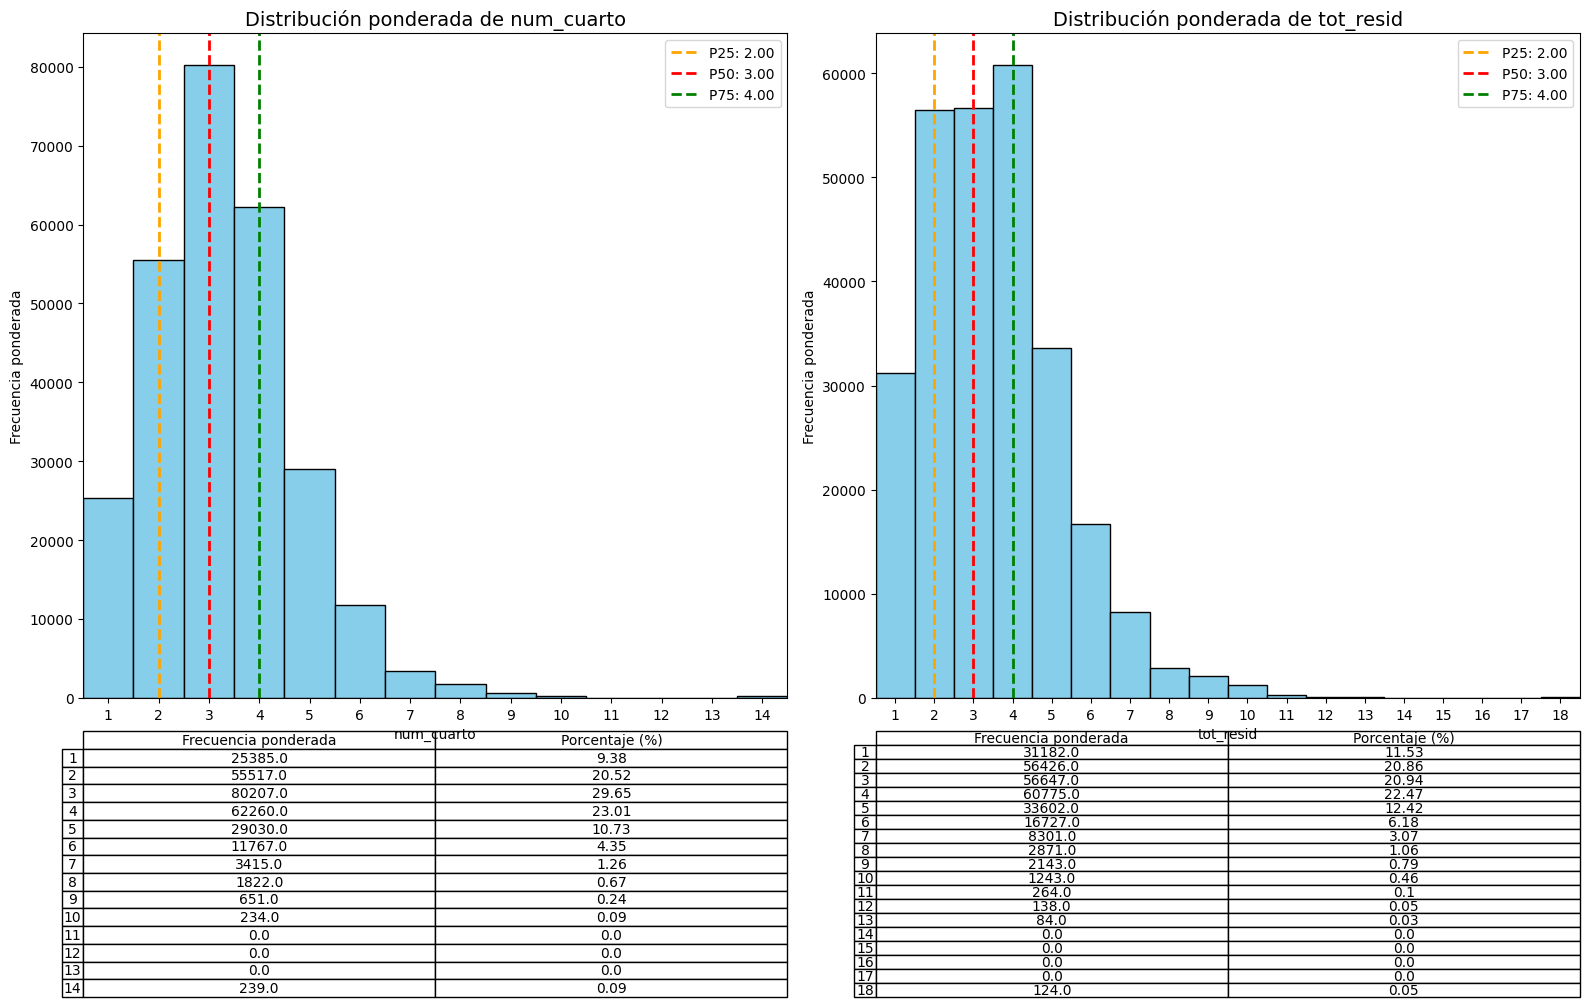

In [29]:
# Esto hay que modificarlo para cada caso 
df = edo_df

cols = ['num_cuarto', 'tot_resid']

fig, axes = plt.subplots(1, 2, figsize=(16, 11))

for ax, col in zip(axes, cols):
    data = df[[col, 'factor']].dropna()
    values = data[col].values
    weights = data['factor'].values

    # Definir bins para enteros
    bins = np.arange(values.min() - 0.5, values.max() + 1.5, 1)

    # Histograma ponderado
    counts, edges, _ = ax.hist(values, bins=bins, weights=weights, color='skyblue', edgecolor='black')

    # Percentiles ponderados
    sorted_idx = np.argsort(values)
    sorted_values = values[sorted_idx]
    sorted_weights = weights[sorted_idx]
    cum_weights = np.cumsum(sorted_weights)
    total_weight = cum_weights[-1]

    def weighted_percentile(sorted_vals, cum_weights, total_weight, percentile):
        idx = np.searchsorted(cum_weights, percentile / 100 * total_weight)
        return sorted_vals[idx]

    p25 = weighted_percentile(sorted_values, cum_weights, total_weight, 25)
    p50 = weighted_percentile(sorted_values, cum_weights, total_weight, 50)
    p75 = weighted_percentile(sorted_values, cum_weights, total_weight, 75)

    # Dibujar líneas de percentiles
    for p, c, label in zip([p25, p50, p75], ['orange', 'red', 'green'], ['P25', 'P50', 'P75']):
        ax.axvline(p, color=c, linestyle='--', linewidth=2, label=f'{label}: {p:.2f}')

    # Configurar eje X con enteros
    ax.set_xticks(np.arange(int(values.min()), int(values.max()) + 1, 1))
    ax.set_xlim(values.min() - 0.5, values.max() + 0.5)
    ax.set_title(f'Distribución ponderada de {col}', fontsize=14)
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia ponderada')
    ax.legend()

    # Crear tabla de conteo ponderado y porcentaje
    percent = counts / counts.sum() * 100
    table_data = np.vstack([counts, percent]).T
    col_labels = ['Frecuencia ponderada', 'Porcentaje (%)']
    ax.table(cellText=np.round(table_data, 2),
             rowLabels=[int(edge + 0.5) for edge in edges[:-1]],
             colLabels=col_labels,
             cellLoc='center',
             rowLoc='center',
             bbox=[0, -0.45, 1, 0.4])  # Ajusta la posición de la tabla debajo del gráfico

plt.tight_layout()
plt.show()

In [30]:
edo_acotado_percentiles_df = edo_df[
    edo_df['num_cuarto'].isin([2, 3, 4]) & 
    edo_df['tot_resid'].isin([2, 3, 4])]

In [31]:
edo_acotado_percentiles_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1046 entries, 3 to 2193
Data columns (total 40 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   folioviv    1046 non-null   int64  
 1   tipo_viv    1046 non-null   object 
 2   mat_pared   1046 non-null   int64  
 3   mat_techos  1046 non-null   int64  
 4   mat_pisos   1046 non-null   object 
 5   cuart_dorm  1046 non-null   int64  
 6   num_cuarto  1046 non-null   int64  
 7   disp_elect  1046 non-null   int64  
 8   focos       1046 non-null   object 
 9   focos_ahor  1046 non-null   object 
 10  combus      1046 non-null   object 
 11  aire_acond  1046 non-null   int64  
 12  calefacc    1046 non-null   int64  
 13  tot_resid   1046 non-null   int64  
 14  ubica_geo   1046 non-null   int64  
 15  est_socio   1046 non-null   int64  
 16  factor      1046 non-null   int64  
 17  num_venti   1046 non-null   int64  
 18  num_ester   1046 non-null   int64  
 19  num_radio   1046 non-null   int6

In [32]:
edo_acotado_cinco_df = edo_df[
    edo_df['num_cuarto'].isin([2, 3, 4, 5, 6]) & 
    edo_df['tot_resid'].isin([1,2, 3, 4, 5])]

In [33]:
edo_acotado_cinco_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1703 entries, 0 to 2193
Data columns (total 40 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   folioviv    1703 non-null   int64  
 1   tipo_viv    1703 non-null   object 
 2   mat_pared   1703 non-null   int64  
 3   mat_techos  1703 non-null   int64  
 4   mat_pisos   1703 non-null   object 
 5   cuart_dorm  1703 non-null   int64  
 6   num_cuarto  1703 non-null   int64  
 7   disp_elect  1703 non-null   int64  
 8   focos       1703 non-null   object 
 9   focos_ahor  1703 non-null   object 
 10  combus      1703 non-null   object 
 11  aire_acond  1703 non-null   int64  
 12  calefacc    1703 non-null   int64  
 13  tot_resid   1703 non-null   int64  
 14  ubica_geo   1703 non-null   int64  
 15  est_socio   1703 non-null   int64  
 16  factor      1703 non-null   int64  
 17  num_venti   1703 non-null   int64  
 18  num_ester   1703 non-null   int64  
 19  num_radio   1703 non-null   int6

In [34]:
viv_original = edo_df['factor'].sum()
viv_percentiles = edo_acotado_percentiles_df['factor'].sum()
viv_cinco = edo_acotado_cinco_df['factor'].sum()

print(f'{viv_original}, {round(viv_original/viv_original*100,2)}% edo_df tiene')
print(f'{viv_percentiles}, {round(viv_percentiles/viv_original*100,2)}% edo_acotado_percentiles_df')
print(f'{viv_cinco}, {round(viv_cinco/viv_original*100,2)}% edo_acotado_cinco_df tiene')

270527, 100.0% edo_df tiene
128153, 47.37% edo_acotado_percentiles_df
209796, 77.55% edo_acotado_cinco_df tiene


In [35]:
edo_df.columns

Index(['folioviv', 'tipo_viv', 'mat_pared', 'mat_techos', 'mat_pisos',
       'cuart_dorm', 'num_cuarto', 'disp_elect', 'focos', 'focos_ahor',
       'combus', 'aire_acond', 'calefacc', 'tot_resid', 'ubica_geo',
       'est_socio', 'factor', 'num_venti', 'num_ester', 'num_radio', 'num_tva',
       'num_tvd', 'num_dvd', 'num_licua', 'num_tosta', 'num_micro',
       'num_refri', 'num_estuf', 'num_lavad', 'num_planc', 'num_maqui',
       'num_aspir', 'num_compu', 'num_lap', 'num_table', 'num_impre',
       'num_juego', 'telefono', 'celular', 'gasto_tri'],
      dtype='object')

In [36]:
print(f'Total gastado en Campeche para la energia electrica {(edo_df['gasto_tri'] * edo_df['factor']).sum():,}')

Total gastado en Campeche para la energia electrica 298,752,137.5


## Cuantos no recibieron subsidio? tarifa DAC

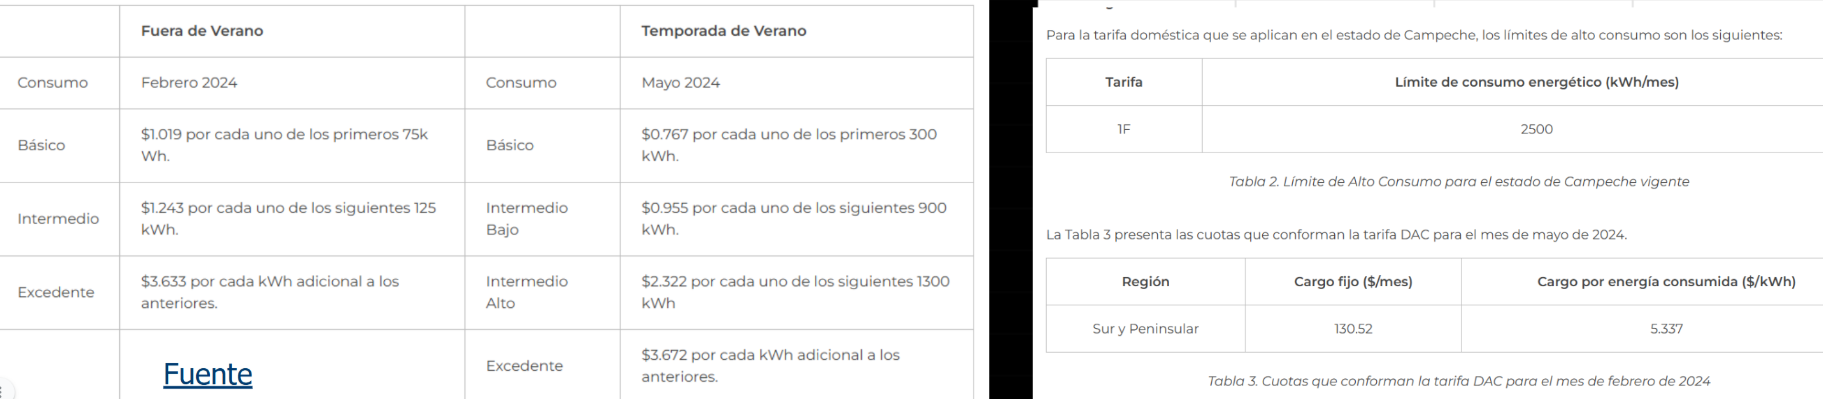

In [37]:
# Primero hay que saber cual es el monto en el que se deha de recibir subsidio
basico = 0.767*300*3*1.22
intermedio_bajo = 0.955*900*3*1.22
intermedio_alto = 2.322*1300*3*1.22
luz_tri_max = (basico + intermedio_bajo + intermedio_alto)
print(f'Maximo de gasto trimestral (considerando impuestos) donde se deja de recibir subsidio {round(luz_tri_max,2):,}')
## fakta quitarle los 22% de impuestos 

Maximo de gasto trimestral (considerando impuestos) donde se deja de recibir subsidio 15,036.01


In [38]:
def clasificar_bloque(df):
    # Definir umbrales
    basico = 0.767 * 300 * 3 * 1.22
    intermedio_bajo = 0.955 * 900 * 3 * 1.22
    intermedio_alto = 2.322 * 1300 * 3 * 1.22
    
    # Función interna para clasificar cada valor
    def get_bloque(gasto):
        if gasto <= basico:
            return "basico"
        elif gasto <= basico + intermedio_bajo:
            return "intermedio_bajo"
        elif gasto <= basico + intermedio_bajo + intermedio_alto:
            return "intermedio_alto"
        elif gasto >= basico + intermedio_bajo + intermedio_alto:
            return "DAC"
        else:
            return np.nan
    
    # Crear la nueva columna
    df["bloque"] = df["gasto_tri"].apply(get_bloque)
    
    return df


In [39]:
edo_df = clasificar_bloque(edo_df)
edo_df

,folioviv,tipo_viv,mat_pared,mat_techos,mat_pisos,cuart_dorm,num_cuarto,disp_elect,focos,focos_ahor,...,num_aspir,num_compu,num_lap,num_table,num_impre,num_juego,telefono,celular,gasto_tri,bloque
0,401161019,1,8,10,3,3,5,1,9,9,...,0,0,0,0,0,0,2,1,NaN,NaN
1,401161020,2,8,10,3,2,2,1,4,4,...,0,0,0,0,0,0,2,1,375.0,basico
2,401161021,1,8,10,3,1,1,1,4,4,...,0,0,0,0,0,0,2,1,582.0,basico
3,401161022,2,8,10,3,2,3,1,5,5,...,0,0,0,0,0,0,2,1,727.5,basico
4,401161024,1,8,10,3,2,2,1,8,8,...,0,0,1,0,0,0,2,1,450.0,basico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2189,461430920,1,6,3,1,2,3,3,2,2,...,0,0,0,0,0,0,2,1,60.0,basico
2190,461430921,1,6,3,2,1,2,1,3,3,...,0,0,0,0,0,0,2,1,NaN,NaN
2191,461430922,1,6,3,2,1,1,1,3,3,...,0,0,0,0,0,0,2,1,60.0,basico
2192,461430923,1,6,3,2,1,1,1,3,3,...,0,0,0,0,0,0,2,1,75.0,basico


## Suponiendo que el subsidio fue planeado de acuerdo a los meses más calidos dentro de la temporada de subsidio

In [40]:
# Datos originales
UTCI = {
    "abril": [39.9, 20.3, 15.6, 17.4, 6.9],
    "mayo": [19.9, 36.6, 13.0, 21.2, 9.3],
    "junio": [22.2, 36.7, 15.0, 22.2, 3.9],
    "julio": [23.0, 34.0, 13.6, 26.1, 3.4],
    "agosto": [22.2, 37.0, 13.4, 22.3, 5.1],
    "septiembre": [18.3, 42.2, 15.4, 21.1, 2.9]
}

index = [
    "UTCI confort",
    "calor moderado",
    "calor fuerte",
    "calor muy fuerte",
    "calor extremo"
]

# Crear DataFrame
df_UTCI = pd.DataFrame(UTCI, index=index)

# Transponer la tabla
df_UTCI = df_UTCI.T

# Mostrar la transpuesta
df_UTCI

,UTCI confort,calor moderado,calor fuerte,calor muy fuerte,calor extremo
abril,39.9,20.3,15.6,17.4,6.9
mayo,19.9,36.6,13.0,21.2,9.3
junio,22.2,36.7,15.0,22.2,3.9
julio,23.0,34.0,13.6,26.1,3.4
agosto,22.2,37.0,13.4,22.3,5.1
septiembre,18.3,42.2,15.4,21.1,2.9


In [41]:
df_UTCI["disconfort"] = 100 - df_UTCI["UTCI confort"]
df_UTCI

,UTCI confort,calor moderado,calor fuerte,calor muy fuerte,calor extremo,disconfort
abril,39.9,20.3,15.6,17.4,6.9,60.1
mayo,19.9,36.6,13.0,21.2,9.3,80.1
junio,22.2,36.7,15.0,22.2,3.9,77.8
julio,23.0,34.0,13.6,26.1,3.4,77.0
agosto,22.2,37.0,13.4,22.3,5.1,77.8
septiembre,18.3,42.2,15.4,21.1,2.9,81.7


Con la Tarifa Eléctrica 1F, la más baja del país, los campechanos tendrán un ahorro en los recibos de entre el 20% al 40%, además el Subsidio a la Energía Eléctrica se mantiene por tercer año consecutivo, con una inversión de $72 millones que aplicará del 1 de abril al 30 de septiembre de 2024. https://www.eleconomista.com.mx/politica/La-gobernadora-Layda-Sansores-San-Roman-firmo-el-convenio-para-la-reduccion-del-costo-de-la-energia-electrica-para-todo-el-estado-20231211-0085.html

In [42]:
df_UTCI["subsidio"] = 72000000*df_UTCI["disconfort"] / df_UTCI["disconfort"].sum()
df_UTCI

,UTCI confort,calor moderado,calor fuerte,calor muy fuerte,calor extremo,disconfort,subsidio
abril,39.9,20.3,15.6,17.4,6.9,60.1,9.520792e+06
mayo,19.9,36.6,13.0,21.2,9.3,80.1,1.268911e+07
junio,22.2,36.7,15.0,22.2,3.9,77.8,1.232475e+07
julio,23.0,34.0,13.6,26.1,3.4,77.0,1.219802e+07
agosto,22.2,37.0,13.4,22.3,5.1,77.8,1.232475e+07
septiembre,18.3,42.2,15.4,21.1,2.9,81.7,1.294257e+07


In [43]:
subsidio_ENIGH = df_UTCI["subsidio"]["agosto"] + df_UTCI["subsidio"]["septiembre"]
print(f'Durante la ENIGH solo se recibio subsidio en agosto y septiembre: {round(subsidio_ENIGH,2):,}')


Durante la ENIGH solo se recibio subsidio en agosto y septiembre: 25,267,326.73


In [44]:
# Los porcentajes fueron elegidos al tanteo
edo_df["subsidio_tri"] = 0.0

edo_df.loc[
    (edo_df["bloque"] == "basico"),
    "subsidio_tri"
] = edo_df["gasto_tri"] * 0.14

edo_df.loc[
    (edo_df["bloque"] == "intermedio_bajo"),
    "subsidio_tri"
] = edo_df["gasto_tri"] *0.08

edo_df.loc[
    (edo_df["bloque"] == "intermedio_alto"),
    "subsidio_tri"
] = edo_df["gasto_tri"] *0.06


In [45]:
print(f'{round( (edo_df["factor"] * edo_df["subsidio_tri"]).sum() ,2):,}')
print(f'{round(subsidio_ENIGH,2):,}')

25,748,284.49
25,267,326.73


In [46]:
total = edo_df.loc[
edo_df["bloque"].isna() 
| (edo_df["bloque"] == "basico")
| (edo_df["bloque"] == "intermedio_bajo")
| (edo_df["bloque"] == "intermedio_alto")
| (edo_df["bloque"] == "DAC")
, "factor"].sum()

print(f'{round(total,2):,}')

270,527


In [47]:
(edo_df["tot_resid"]*edo_df["factor"]).sum()

np.int64(946123)

In [48]:
edo_df["gasto_tri_neto"] = (edo_df["gasto_tri"] + edo_df["subsidio_tri"])/1.22
edo_df

,folioviv,tipo_viv,mat_pared,mat_techos,mat_pisos,cuart_dorm,num_cuarto,disp_elect,focos,focos_ahor,...,num_lap,num_table,num_impre,num_juego,telefono,celular,gasto_tri,bloque,subsidio_tri,gasto_tri_neto
0,401161019,1,8,10,3,3,5,1,9,9,...,0,0,0,0,2,1,NaN,NaN,0.00,NaN
1,401161020,2,8,10,3,2,2,1,4,4,...,0,0,0,0,2,1,375.0,basico,52.50,350.409836
2,401161021,1,8,10,3,1,1,1,4,4,...,0,0,0,0,2,1,582.0,basico,81.48,543.836066
3,401161022,2,8,10,3,2,3,1,5,5,...,0,0,0,0,2,1,727.5,basico,101.85,679.795082
4,401161024,1,8,10,3,2,2,1,8,8,...,1,0,0,0,2,1,450.0,basico,63.00,420.491803
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2189,461430920,1,6,3,1,2,3,3,2,2,...,0,0,0,0,2,1,60.0,basico,8.40,56.065574
2190,461430921,1,6,3,2,1,2,1,3,3,...,0,0,0,0,2,1,NaN,NaN,0.00,NaN
2191,461430922,1,6,3,2,1,1,1,3,3,...,0,0,0,0,2,1,60.0,basico,8.40,56.065574
2192,461430923,1,6,3,2,1,1,1,3,3,...,0,0,0,0,2,1,75.0,basico,10.50,70.081967


In [49]:
def calcular_kWh_tri(row):
    if pd.isna(row['bloque']):
        return np.nan
    elif row['bloque'] == 'DAC':
        return (row['gasto_tri_neto'] - 130.52) / 5.337
    elif row['bloque'] == 'basico':
        return row['gasto_tri_neto'] / 0.767
    elif row['bloque'] == 'intermedio_bajo':
        return (row['gasto_tri_neto'] - 300*0.767) / 0.955 + 300
    elif row['bloque'] == 'intermedio_alto':
        return (row['gasto_tri_neto'] - 300*0.767 - 900*0.955) / 2.322 + 300 + 900
    else:
        return np.nan  # Por si aparece un valor inesperado en 'bloque'

# Crear la nueva columna kWh_tri
edo_df['kWh_tri'] = edo_df.apply(calcular_kWh_tri, axis=1)
edo_df

,folioviv,tipo_viv,mat_pared,mat_techos,mat_pisos,cuart_dorm,num_cuarto,disp_elect,focos,focos_ahor,...,num_table,num_impre,num_juego,telefono,celular,gasto_tri,bloque,subsidio_tri,gasto_tri_neto,kWh_tri
0,401161019,1,8,10,3,3,5,1,9,9,...,0,0,0,2,1,NaN,NaN,0.00,NaN,NaN
1,401161020,2,8,10,3,2,2,1,4,4,...,0,0,0,2,1,375.0,basico,52.50,350.409836,456.857674
2,401161021,1,8,10,3,1,1,1,4,4,...,0,0,0,2,1,582.0,basico,81.48,543.836066,709.043110
3,401161022,2,8,10,3,2,3,1,5,5,...,0,0,0,2,1,727.5,basico,101.85,679.795082,886.303888
4,401161024,1,8,10,3,2,2,1,8,8,...,0,0,0,2,1,450.0,basico,63.00,420.491803,548.229209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2189,461430920,1,6,3,1,2,3,3,2,2,...,0,0,0,2,1,60.0,basico,8.40,56.065574,73.097228
2190,461430921,1,6,3,2,1,2,1,3,3,...,0,0,0,2,1,NaN,NaN,0.00,NaN,NaN
2191,461430922,1,6,3,2,1,1,1,3,3,...,0,0,0,2,1,60.0,basico,8.40,56.065574,73.097228
2192,461430923,1,6,3,2,1,1,1,3,3,...,0,0,0,2,1,75.0,basico,10.50,70.081967,91.371535


In [99]:
# 1. = Del servicio público
# 2. = De una planta particular
# 3. = De panel solar
# 4. = De otra fuente
# 5. = No tiene luz eléctrica
edo_df_CFE = edo_df[edo_df['disp_elect'] == 1].copy()
edo_df_CFE['factor'].sum()

np.float64(267262.0)

In [100]:
viv_original

np.int64(270527)

In [101]:
viv_original - edo_df_CFE['factor'].sum()

np.float64(3265.0)

In [102]:
edo_df.loc[edo_df['gasto_tri'] < 70.17, 'factor'].sum()

np.float64(6870.0)

In [103]:
edo_df_CFE_2 = edo_df_CFE.loc[edo_df_CFE['gasto_tri'] >= 70.17].copy()
edo_df_CFE_2['factor'].sum()

np.float64(242240.0)

In [104]:
edo_df_CFE_2.columns

Index(['folioviv', 'tipo_viv', 'mat_pared', 'mat_techos', 'mat_pisos',
       'cuart_dorm', 'num_cuarto', 'disp_elect', 'focos', 'focos_ahor',
       'combus', 'aire_acond', 'calefacc', 'tot_resid', 'ubica_geo',
       'est_socio', 'factor', 'num_venti', 'num_ester', 'num_radio', 'num_tva',
       'num_tvd', 'num_dvd', 'num_licua', 'num_tosta', 'num_micro',
       'num_refri', 'num_estuf', 'num_lavad', 'num_planc', 'num_maqui',
       'num_aspir', 'num_compu', 'num_lap', 'num_table', 'num_impre',
       'num_juego', 'telefono', 'celular', 'gasto_tri', 'bloque',
       'subsidio_tri', 'gasto_tri_neto', 'kWh_tri'],
      dtype='object')

In [105]:
(edo_df_CFE_2['factor'].sum()/viv_original)*100

np.float64(89.5437423990951)

In [106]:
viv_sin_consumo = edo_df.loc[edo_df["kWh_tri"].isna(), "factor"].sum()
viv_con_consumo = edo_df.loc[edo_df["kWh_tri"].notna(), "factor"].sum()

print(f'''Se consiguieron: {round(viv_con_consumo,2):,} ({round(100*viv_con_consumo/edo_df['factor'].sum(),2):,}%) viviendas con consumo 
y {round(viv_sin_consumo,2):,} ({round(100*viv_sin_consumo/edo_df['factor'].sum(),2):,}%) viviendas sin consumo ''')

Se consiguieron: 250,323.0 (92.53%) viviendas con consumo 
y 20,204.0 (7.47%) viviendas sin consumo 


In [107]:
viv_sin_consumo = edo_df_CFE_2.loc[edo_df_CFE_2["kWh_tri"].isna(), "factor"].sum()
viv_con_consumo = edo_df_CFE_2.loc[edo_df_CFE_2["kWh_tri"].notna(), "factor"].sum()

print(f'''Se consiguieron: {round(viv_con_consumo,2):,} ({round(100*viv_con_consumo/edo_df['factor'].sum(),2):,}%) viviendas con consumo 
y {round(viv_sin_consumo,2):,} ({round(100*viv_sin_consumo/edo_df['factor'].sum(),2):,}%) viviendas sin consumo ''')

Se consiguieron: 242,240.0 (89.54%) viviendas con consumo 
y 0.0 (0.0%) viviendas sin consumo 


In [97]:
viv_sin_consumo = edo_df_CFE.loc[edo_df_CFE["kWh_tri"].isna(), "factor"].sum()
viv_con_consumo = edo_df_CFE.loc[edo_df_CFE["kWh_tri"].notna(), "factor"].sum()

print(f'''Se consiguieron: {round(viv_con_consumo,2):,} ({round(100*viv_con_consumo/edo_df['factor'].sum(),2):,}%) viviendas con consumo 
y {round(viv_sin_consumo,2):,} ({round(100*viv_sin_consumo/edo_df['factor'].sum(),2):,}%) viviendas sin consumo ''')

Se consiguieron: 248,729.0 (91.94%) viviendas con consumo 
y 18,533.0 (6.85%) viviendas sin consumo 


### Caracteristicas de la vivienda 
'folioviv', 'mat_pared', 'mat_techos', 'mat_pisos', 'cuart_dorm',
'num_cuarto', **'tot_resid'**, 'ubica_geo','est_socio', 
'factor',**'gasto_tri'**
'disp_elect' Esta varaible es solo para limpiar y quitar los que no tienen acceso al servicio de electricidad. 
### Cargas
'focos', 'focos_ahor', 'combus', 'aire_acond', 'calefacc', 
'num_venti', 'num_ester', 'num_radio', 'num_tva',
'num_tvd', 'num_dvd', 'num_licua', 'num_tosta', 'num_micro',
'num_refri', 'num_estuf', 'num_lavad', 'num_planc', 'num_maqui',
'num_aspir', 'num_compu', 'num_lap', 'num_table', 'num_impre',
'num_juego', 'telefono', 'celular'

### Utiles para agrupar
'aire_acond', 'calefacc', 'est_socio', 'num_cuarto', 'tot_resid'
'ubica_geo' Para otro analisis si, aca es un solo municipio

### Variables que me gustaria obtener con modelos o con otras encuestas
Consumo en kWh, superficie de construccion, factores relacionados con horarios de ocupacion y consumo

In [50]:
cols = edo_df.columns.difference(['bloque'])

edo_df[cols] = (
    edo_df[cols]
    .replace(r'^\s*$', np.nan, regex=True)
    .infer_objects(copy=False)
    .astype(float)
)

edo_df.dtypes

C:\Users\roele\AppData\Local\Temp\ipykernel_27140\450690371.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(r'^\s*$', np.nan, regex=True)


folioviv          float64
tipo_viv          float64
mat_pared         float64
mat_techos        float64
mat_pisos         float64
cuart_dorm        float64
num_cuarto        float64
disp_elect        float64
focos             float64
focos_ahor        float64
combus            float64
aire_acond        float64
calefacc          float64
tot_resid         float64
ubica_geo         float64
est_socio         float64
factor            float64
num_venti         float64
num_ester         float64
num_radio         float64
num_tva           float64
num_tvd           float64
num_dvd           float64
num_licua         float64
num_tosta         float64
num_micro         float64
num_refri         float64
num_estuf         float64
num_lavad         float64
num_planc         float64
num_maqui         float64
num_aspir         float64
num_compu         float64
num_lap           float64
num_table         float64
num_impre         float64
num_juego         float64
telefono          float64
celular     

In [51]:
edo_df.isna().sum().sort_values(ascending=False)

bloque            163
gasto_tri_neto    163
kWh_tri           163
gasto_tri         163
focos              10
focos_ahor         10
mat_pisos           0
cuart_dorm          0
mat_techos          0
mat_pared           0
folioviv            0
tipo_viv            0
aire_acond          0
combus              0
num_cuarto          0
disp_elect          0
calefacc            0
tot_resid           0
ubica_geo           0
est_socio           0
num_tva             0
num_tvd             0
num_dvd             0
num_licua           0
factor              0
num_venti           0
num_ester           0
num_radio           0
num_estuf           0
num_refri           0
num_micro           0
num_tosta           0
num_lavad           0
num_planc           0
num_maqui           0
num_aspir           0
num_impre           0
num_table           0
num_lap             0
num_compu           0
celular             0
telefono            0
num_juego           0
subsidio_tri        0
dtype: int64

In [52]:
edo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2194 entries, 0 to 2193
Data columns (total 44 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   folioviv        2194 non-null   float64
 1   tipo_viv        2194 non-null   float64
 2   mat_pared       2194 non-null   float64
 3   mat_techos      2194 non-null   float64
 4   mat_pisos       2194 non-null   float64
 5   cuart_dorm      2194 non-null   float64
 6   num_cuarto      2194 non-null   float64
 7   disp_elect      2194 non-null   float64
 8   focos           2184 non-null   float64
 9   focos_ahor      2184 non-null   float64
 10  combus          2194 non-null   float64
 11  aire_acond      2194 non-null   float64
 12  calefacc        2194 non-null   float64
 13  tot_resid       2194 non-null   float64
 14  ubica_geo       2194 non-null   float64
 15  est_socio       2194 non-null   float64
 16  factor          2194 non-null   float64
 17  num_venti       2194 non-null   f

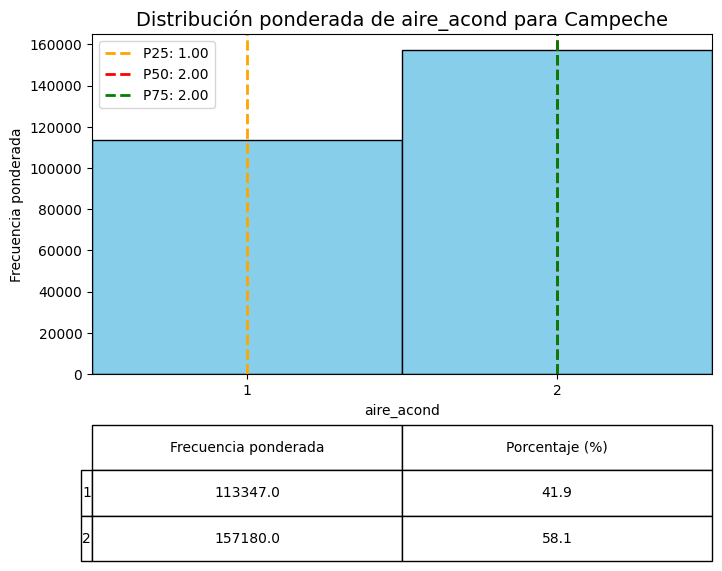

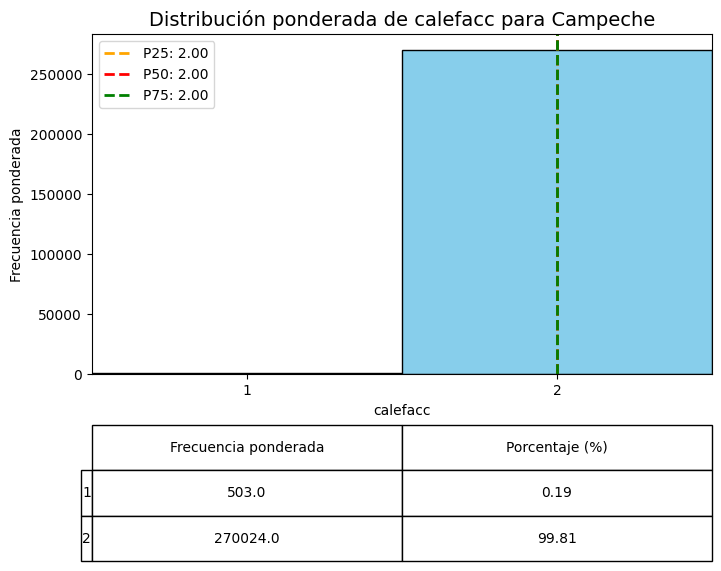

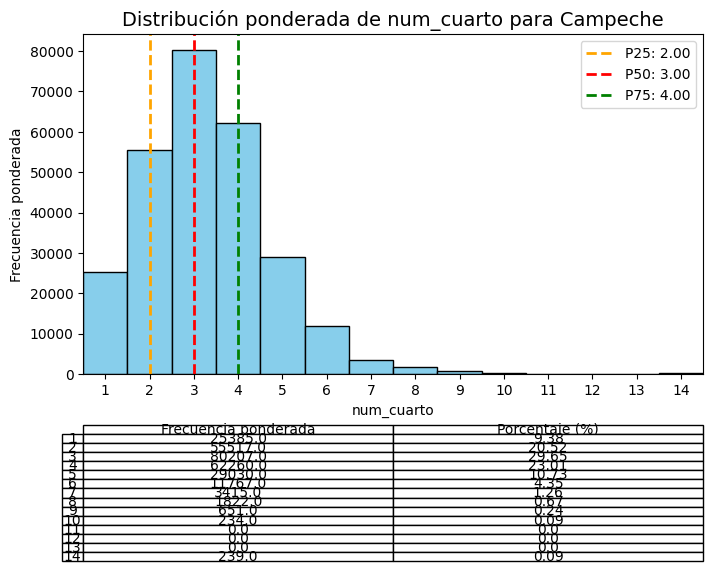

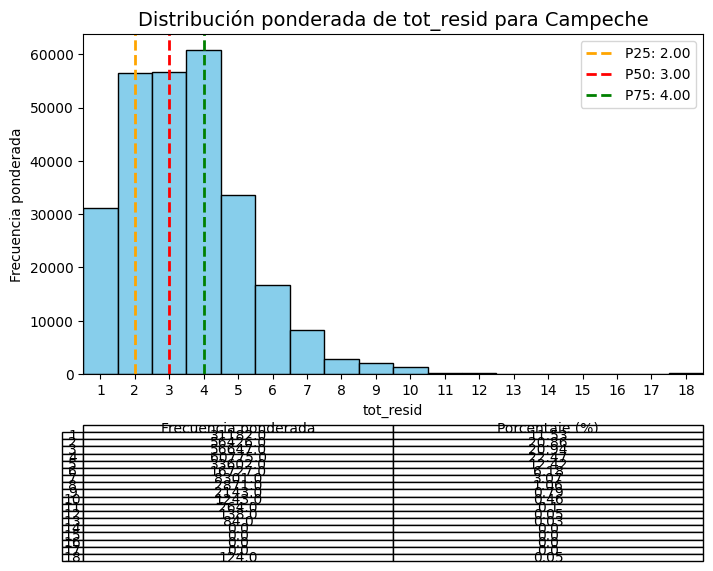

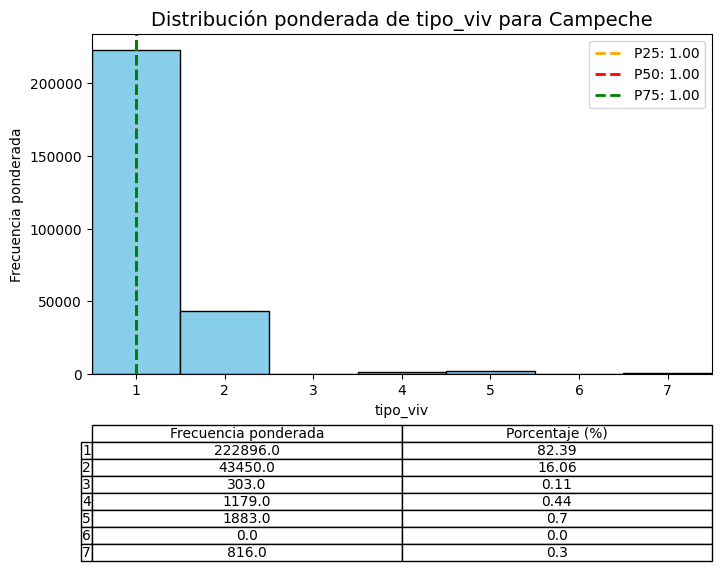

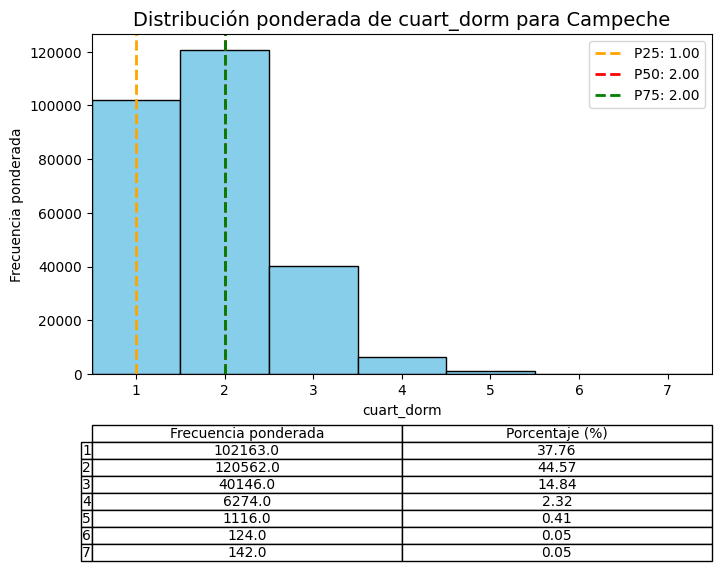

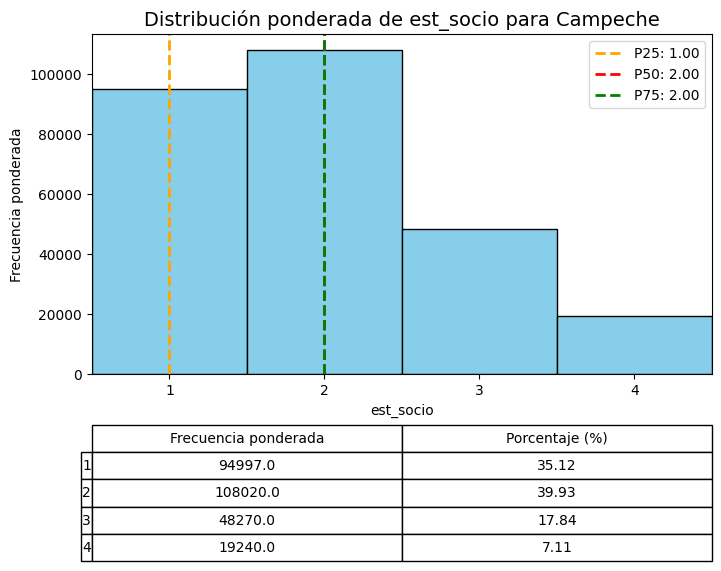

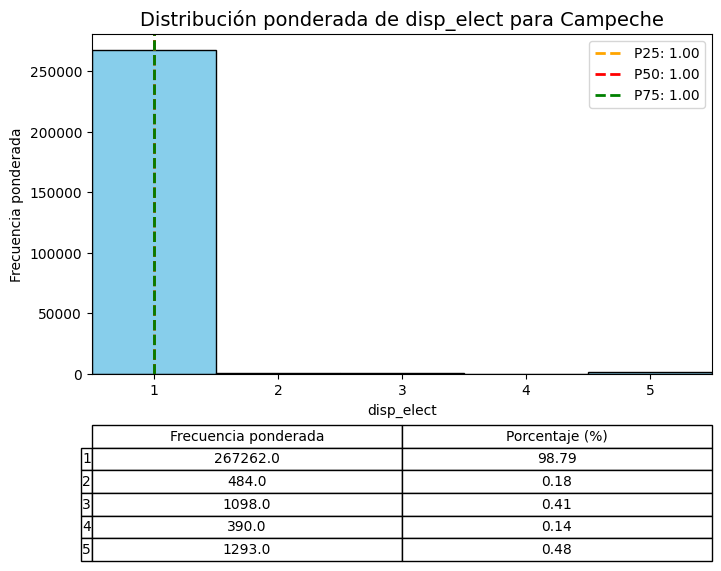

In [53]:
# Esto hay que modificarlo para cada caso 
df = edo_df
nombre = nombre_edo
cols = ['aire_acond', 'calefacc', 'num_cuarto', 'tot_resid', 'tipo_viv', 'cuart_dorm','est_socio','disp_elect']

for col in cols:
    # Reducimos la altura de la figura (figsize: ancho, alto)
    fig, ax = plt.subplots(figsize=(8, 5))  # antes era (8,6)
    
    data = df[[col, 'factor']].dropna()
    values = data[col].values
    weights = data['factor'].values

    # Definir bins para enteros
    bins = np.arange(values.min() - 0.5, values.max() + 1.5, 1)

    # Histograma ponderado
    counts, edges, _ = ax.hist(values, bins=bins, weights=weights, color='skyblue', edgecolor='black')

    # Percentiles ponderados
    sorted_idx = np.argsort(values)
    sorted_values = values[sorted_idx]
    sorted_weights = weights[sorted_idx]
    cum_weights = np.cumsum(sorted_weights)
    total_weight = cum_weights[-1]

    def weighted_percentile(sorted_vals, cum_weights, total_weight, percentile):
        idx = np.searchsorted(cum_weights, percentile / 100 * total_weight)
        return sorted_vals[idx]

    p25 = weighted_percentile(sorted_values, cum_weights, total_weight, 25)
    p50 = weighted_percentile(sorted_values, cum_weights, total_weight, 50)
    p75 = weighted_percentile(sorted_values, cum_weights, total_weight, 75)

    # Dibujar líneas de percentiles
    for p, c, label in zip([p25, p50, p75], ['orange', 'red', 'green'], ['P25', 'P50', 'P75']):
        ax.axvline(p, color=c, linestyle='--', linewidth=2, label=f'{label}: {p:.2f}')

    # Configurar eje X con enteros
    ax.set_xticks(np.arange(int(values.min()), int(values.max()) + 1, 1))
    ax.set_xlim(values.min() - 0.5, values.max() + 0.5)
    ax.set_title(f'Distribución ponderada de {col} para {nombre}', fontsize=14)
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia ponderada')
    ax.legend()

    # Crear tabla de conteo ponderado y porcentaje debajo del gráfico
    percent = counts / counts.sum() * 100
    table_data = np.vstack([counts, percent]).T
    col_labels = ['Frecuencia ponderada', 'Porcentaje (%)']
    ax.table(cellText=np.round(table_data, 2),
             rowLabels=[int(edge + 0.5) for edge in edges[:-1]],
             colLabels=col_labels,
             cellLoc='center',
             rowLoc='center',
             bbox=[0, -0.55, 1, 0.4])  # Ajusta según sea necesario

    # Ajustar márgenes para que la tabla quepa
    plt.subplots_adjust(bottom=0.2)
    plt.show()


In [54]:
edo_df.columns

Index(['folioviv', 'tipo_viv', 'mat_pared', 'mat_techos', 'mat_pisos',
       'cuart_dorm', 'num_cuarto', 'disp_elect', 'focos', 'focos_ahor',
       'combus', 'aire_acond', 'calefacc', 'tot_resid', 'ubica_geo',
       'est_socio', 'factor', 'num_venti', 'num_ester', 'num_radio', 'num_tva',
       'num_tvd', 'num_dvd', 'num_licua', 'num_tosta', 'num_micro',
       'num_refri', 'num_estuf', 'num_lavad', 'num_planc', 'num_maqui',
       'num_aspir', 'num_compu', 'num_lap', 'num_table', 'num_impre',
       'num_juego', 'telefono', 'celular', 'gasto_tri', 'bloque',
       'subsidio_tri', 'gasto_tri_neto', 'kWh_tri'],
      dtype='object')